# Notebook 02 — Prétraitement des données
Nettoyage, encodage, et préparation pour la PCA et K-Means.

In [1]:
import sys
sys.path.append('..')
import pandas as pd
from src.preprocessing import clean_data, encode_data, get_numeric_features

df_raw = pd.read_csv('../data/raw/StudentsPerformance.csv')
print('Dataset brut :', df_raw.shape)
df_raw.head()

Dataset brut : (1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [2]:
# Étape 1 : Nettoyage
df_clean = clean_data(df_raw)
print('\nShape après nettoyage :', df_clean.shape)
df_clean.describe().round(2)

  [Preprocessing] Lignes avant : 1000
  [Preprocessing] Doublons détectés : 0
  [Preprocessing] Valeurs manquantes : 0
  [Preprocessing] Lignes après nettoyage : 1000

Shape après nettoyage : (1000, 8)


,math score,reading score,writing score
count,1000.00,1000.00,1000.00
mean,66.09,69.17,68.05
std,15.16,14.60,15.20
min,0.00,17.00,10.00
25%,57.00,59.00,57.75
50%,66.00,70.00,69.00
75%,77.00,79.00,79.00
max,100.00,100.00,100.00


In [3]:
# Étape 2 : Features numériques pour la PCA
# Seuls les 3 scores numériques sont utilisés
df_numeric = get_numeric_features(df_clean)
print('Features numériques :', list(df_numeric.columns))
print('Shape :', df_numeric.shape)
df_numeric.describe().round(2)

Features numériques : ['math score', 'reading score', 'writing score']
Shape : (1000, 3)


,math score,reading score,writing score
count,1000.00,1000.00,1000.00
mean,66.09,69.17,68.05
std,15.16,14.60,15.20
min,0.00,17.00,10.00
25%,57.00,59.00,57.75
50%,66.00,70.00,69.00
75%,77.00,79.00,79.00
max,100.00,100.00,100.00


In [4]:
# Étape 3 : Standardisation (aperçu)
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler_demo = StandardScaler()
scaled = scaler_demo.fit_transform(df_numeric)
df_scaled = pd.DataFrame(scaled, columns=df_numeric.columns)
print('Après standardisation (moyenne ≈ 0, écart-type ≈ 1) :')
df_scaled.describe().round(3)

Après standardisation (moyenne ≈ 0, écart-type ≈ 1) :


,math score,reading score,writing score
count,1000.000,1000.000,1000.000
mean,0.000,0.000,-0.000
std,1.001,1.001,1.001
min,-4.361,-3.575,-3.822
25%,-0.600,-0.697,-0.678
50%,-0.006,0.057,0.062
75%,0.720,0.674,0.721
max,2.238,2.113,2.103


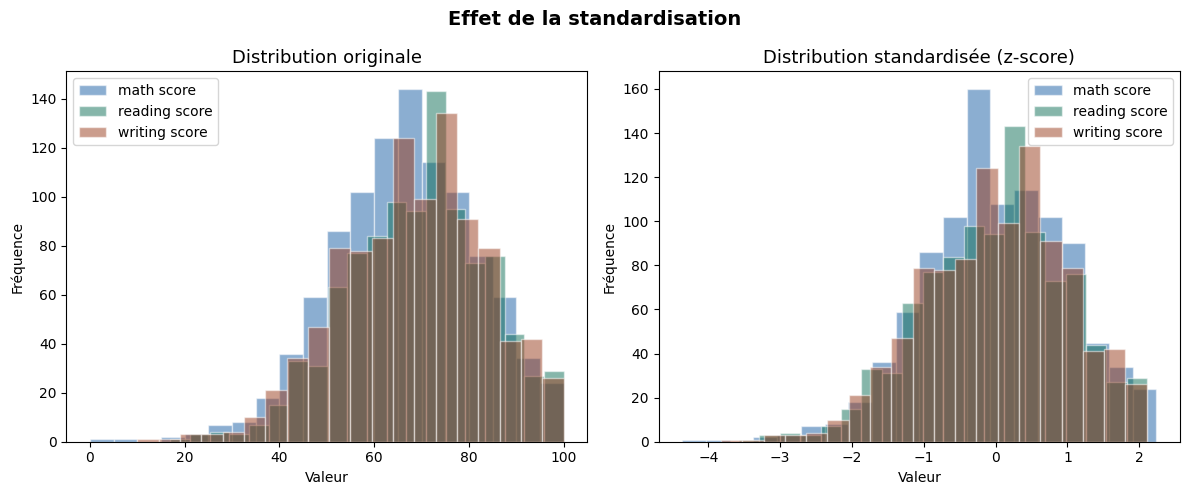

In [5]:
# Comparaison avant / après standardisation
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cols = ['math score', 'reading score', 'writing score']
colors = ['#185FA5', '#0F6E56', '#993C1D']
for col, color in zip(cols, colors):
    axes[0].hist(df_numeric[col], bins=20, alpha=0.5, label=col, color=color, edgecolor='white')
    axes[1].hist(df_scaled[col], bins=20, alpha=0.5, label=col, color=color, edgecolor='white')
axes[0].set_title('Distribution originale', fontsize=13)
axes[1].set_title('Distribution standardisée (z-score)', fontsize=13)
for ax in axes:
    ax.legend()
    ax.set_xlabel('Valeur')
    ax.set_ylabel('Fréquence')
plt.suptitle('Effet de la standardisation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/standardisation.png', dpi=150)
plt.show()

In [6]:
# Encodage des variables catégorielles (pour référence future)
df_encoded = encode_data(df_clean)
print('Shape encodé (toutes colonnes) :', df_encoded.shape)
print('Colonnes :', list(df_encoded.columns))
print('\nNote : Pour la PCA, on utilise uniquement les 3 colonnes numériques.')

  [Preprocessing] Colonnes après encodage : 15
Shape encodé (toutes colonnes) : (1000, 15)
Colonnes : ['math score', 'reading score', 'writing score', 'gender_male', 'race/ethnicity_group B', 'race/ethnicity_group C', 'race/ethnicity_group D', 'race/ethnicity_group E', "parental level of education_bachelor's degree", 'parental level of education_high school', "parental level of education_master's degree", 'parental level of education_some college', 'parental level of education_some high school', 'lunch_standard', 'test preparation course_none']

Note : Pour la PCA, on utilise uniquement les 3 colonnes numériques.
